In [1]:
# Solar Battery Optimization: A Predict-Then-Optimize Pipeline

This notebook demonstrates an end-to-end pipeline that:
1. Forecasts solar generation using Random Forest
2. Optimizes battery charge/discharge scheduling using MILP
3. Minimizes grid electricity costs over a 24-hour horizon

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_p1_gen_data = pd.read_csv("Plant_1_Generation_Data.csv")
df_p1_weather_data = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

df_p2_gen_data = pd.read_csv("Plant_2_Generation_Data.csv")
df_p2_weather_data = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

In [2]:
print(df_p1_gen_data.columns.tolist)
print(df_p1_weather_data.columns.tolist)
print()
print(df_p1_gen_data.head())
print()
print(df_p1_weather_data.head())
print()
print(df_p1_gen_data.dtypes)
print()
print(df_p1_weather_data['DATE_TIME'].iloc[0])

<bound method IndexOpsMixin.tolist of Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')>

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  

             DATE_TIME  PLANT_ID       SOURCE_KEY  AM

The following issues were observed from the above cell


1.   There are multiple source keys for the same plant in the same hour in the gen_data file. this means we cannot merge the weather file with this one directly
2.   Date formats are different DD-MM-YYYY vs the reverse

On pd.merge 'how'
left — keep all generation timestamps, fill weather columns with NaN if no match
right — keep all weather timestamps, fill generation columns with NaN if no match
inner — only keep timestamps that exist in both tables
outer — keep everything from both, NaN where no match

In [14]:
#Fix datetime formats
df_p1_gen_data['DATE_TIME'] = pd.to_datetime(df_p1_gen_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
df_p1_weather_data['DATE_TIME'] = pd.to_datetime(df_p1_weather_data['DATE_TIME'])
#aggregate all inverter outputs into plant level totals
df_p1_gen_data_agg = df_p1_gen_data.groupby('DATE_TIME').agg(
    DC_POWER = ('DC_POWER','sum'),
    AC_POWER = ('AC_POWER','sum'),
    DAILY_YIELD = ('DAILY_YIELD','sum'),

).reset_index()

#merge this aggregated one with weather
df_p1_merged = pd.merge(df_p1_gen_data_agg, df_p1_weather_data[['DATE_TIME', 'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE', 'IRRADIATION']], on='DATE_TIME', how='inner')
print(df_p1_merged.shape)
print(df_p1_merged.head())

(2058, 7)
            DATE_TIME  DC_POWER  AC_POWER  DAILY_YIELD  AMBIENT_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0       0.0          0.0            25.184316   
1 2020-05-15 00:15:00       0.0       0.0          0.0            25.084589   
2 2020-05-15 00:30:00       0.0       0.0          0.0            24.935753   
3 2020-05-15 00:45:00       0.0       0.0          0.0            24.846130   
4 2020-05-15 01:00:00       0.0       0.0          0.0            24.621525   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.761668          0.0  
2           22.592306          0.0  
3           22.360852          0.0  
4           22.165423          0.0  


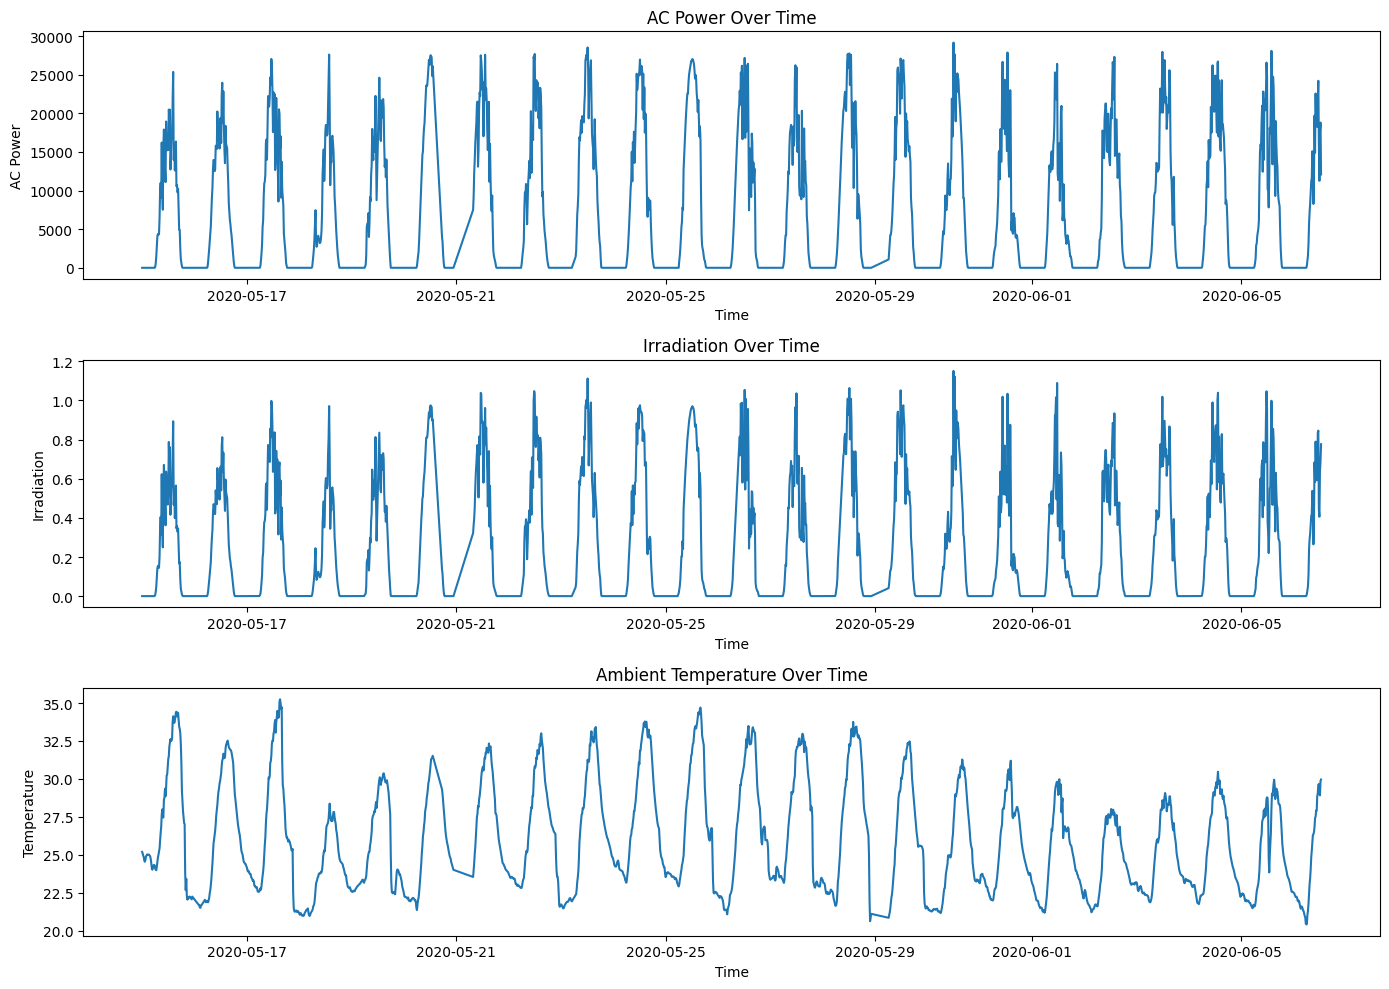

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14,10))

#AC power over time
axes[0].plot(df_p1_merged['DATE_TIME'], df_p1_merged['AC_POWER'])
axes[0].set_title('AC Power Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('AC Power')

#irradiation over time
axes[1].plot(df_p1_merged['DATE_TIME'], df_p1_merged['IRRADIATION'])
axes[1].set_title('Irradiation Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Irradiation')

#temperature over time
axes[2].plot(df_p1_merged['DATE_TIME'], df_p1_merged['AMBIENT_TEMPERATURE'])
axes[2].set_title('Ambient Temperature Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Temperature')

plt.tight_layout()
plt.show()

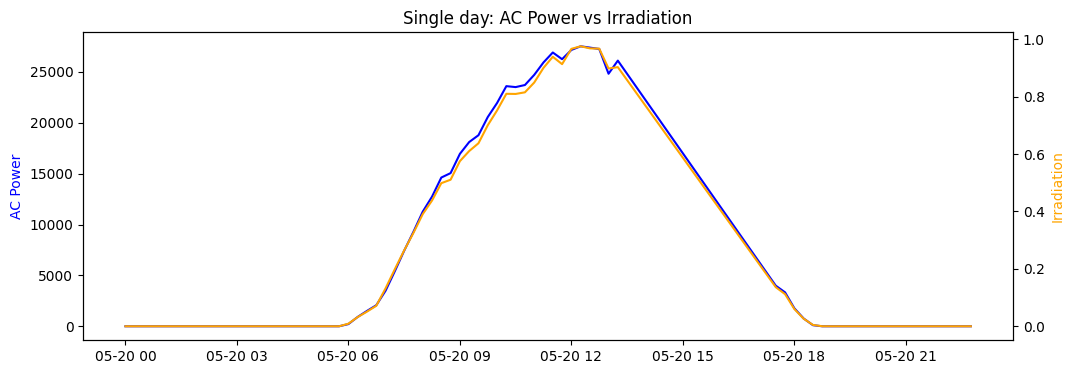

In [16]:
one_day = df_p1_merged[df_p1_merged['DATE_TIME'].dt.date == df_p1_merged['DATE_TIME'].dt.date.unique()[5]]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(one_day['DATE_TIME'], one_day['AC_POWER'], color='blue', label='AC Power')
ax2.plot(one_day['DATE_TIME'], one_day['IRRADIATION'], color='orange', label='Irradiation')

ax1.set_ylabel('AC Power', color='blue')
ax2.set_ylabel('Irradiation', color='orange')
plt.title('Single day: AC Power vs Irradiation')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#features and target
features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR']
df_p1_merged['HOUR'] = df_p1_merged['DATE_TIME'].dt.hour + df_p1_merged['DATE_TIME'].dt.minute/60
X = df_p1_merged[features]
y = df_p1_merged['AC_POWER']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE:  {mae:.1f} W')
print(f'RMSE: {rmse:.1f} W')
print(f'Max AC Power in data: {y.max():.1f} W')
print(f'MAE as % of max: {100*mae/y.max():.1f}%')

MAE:  506.9 W
RMSE: 923.7 W
Max AC Power in data: 29150.2 W
MAE as % of max: 1.7%


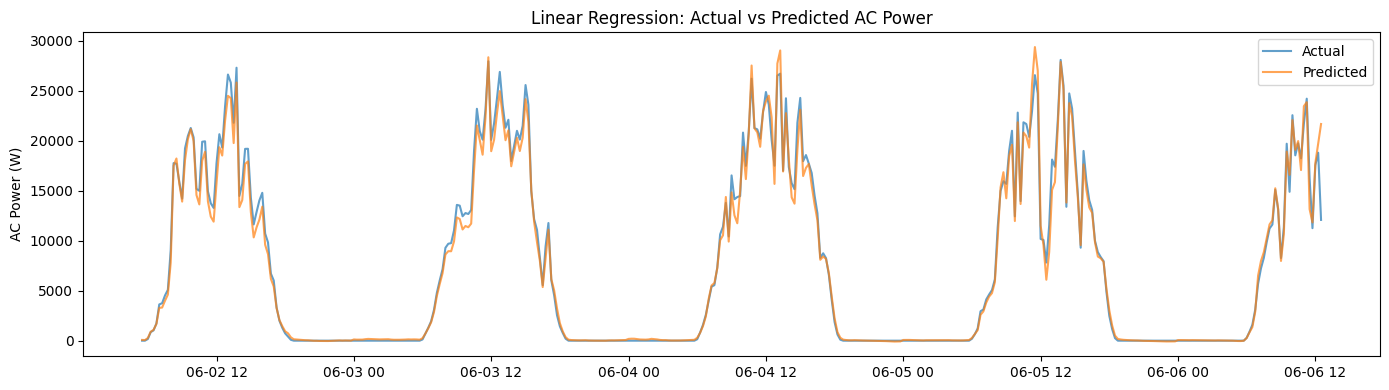

In [18]:
# plot predictions vs actual on test set
test_dates = df_p1_merged['DATE_TIME'].iloc[len(X_train):]

plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test.values, label='Actual', alpha=0.7)
plt.plot(test_dates, y_pred, label='Predicted', alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted AC Power')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# lag feature - what was AC_POWER 15 minutes ago
# df_p1_merged['AC_POWER_LAG1'] = df_p1_merged['AC_POWER'].shift(1)

# rate of change of irradiation - is it going up or down?
df_p1_merged['IRRADIATION_DIFF'] = df_p1_merged['IRRADIATION'].diff()

# drop the first row which now has NaN
df_feat = df_p1_merged.dropna()

features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR', 'IRRADIATION_DIFF']
X = df_feat[features]
y = df_feat['AC_POWER']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f'MAE:  {mae2:.1f} W')
print(f'RMSE: {rmse2:.1f} W')
print(f'MAE as % of max: {100*mae2/y.max():.1f}%')

MAE:  499.7 W
RMSE: 907.7 W
MAE as % of max: 1.7%


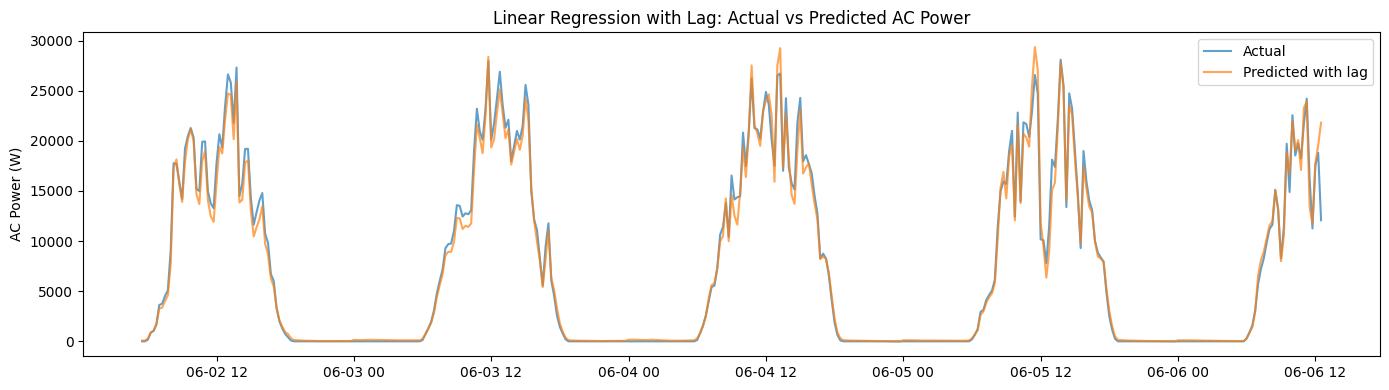

In [20]:
test_dates = df_feat['DATE_TIME'].iloc[len(X_train):]

plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test.values, label='Actual', alpha=0.7)
plt.plot(test_dates, y_pred2, label='Predicted with lag', alpha=0.7)
plt.title('Linear Regression with Lag: Actual vs Predicted AC Power')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'MAE:  {mae_rf:.1f} W')
print(f'RMSE: {rmse_rf:.1f} W')
print(f'MAE as % of max: {100*mae_rf/y.max():.1f}%')

# feature importances
print()
for feat, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f'{feat:25s}: {imp:.4f}')

MAE:  351.4 W
RMSE: 821.4 W
MAE as % of max: 1.2%

IRRADIATION              : 0.9971
IRRADIATION_DIFF         : 0.0009
MODULE_TEMPERATURE       : 0.0008
HOUR                     : 0.0007
AMBIENT_TEMPERATURE      : 0.0005


In [13]:
print(df_p1_merged.shape)
print(df_p1_merged['DATE_TIME'].min())
print(df_p1_merged['DATE_TIME'].max())

(2058, 10)
2020-05-15 00:00:00
2020-06-06 12:30:00


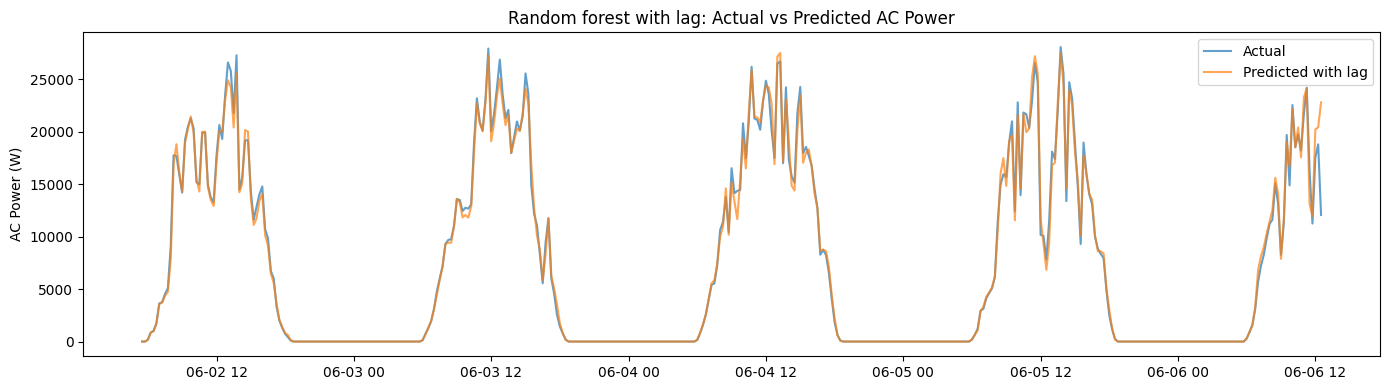

In [11]:
test_dates = df_feat['DATE_TIME'].iloc[len(X_train):]

plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test.values, label='Actual', alpha=0.7)
plt.plot(test_dates, y_pred_rf, label='Predicted with lag', alpha=0.7)
plt.title('Random forest with lag: Actual vs Predicted AC Power')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 70.9 MB/s eta 0:00:00


In [25]:
# daily total should be sum of 15min intervals converted to hours
# each reading is 15 min = 0.25 hours
# energy = power * time
daily_energy = df_p1_merged.groupby(df_p1_merged['DATE_TIME'].dt.date)['AC_POWER'].sum() * 0.25
print(f"Average daily energy: {daily_energy.mean():.1f} Wh")
print(f"Average daily energy: {daily_energy.mean()/1000:.1f} kWh")

Average daily energy: 154860.5 Wh
Average daily energy: 154.9 kWh


In [28]:
# in Watts (keeping consistent with your data)
BATTERY_CAPACITY = 50000  # 50 kWh battery
P_MIN = 10000             # 20% minimum charge (10 kWh)
P_MAX = 50000             # 100% maximum charge (50 kWh)
CHARGE_RATE = 12500       # max 12.5 kW charge per 15 min = 50 kW/hr rate
DISCHARGE_RATE = 12500    # same for discharge

# electricity prices (arbitrary for now, ratio matters more than absolute values)
C_BUY = 8                 # cost per kWh to buy from grid (Rs)
C_SELL = 4                # revenue per kWh to sell to grid (Rs)

In [38]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# ── 1. GET SOLAR PREDICTIONS FROM ML MODEL ──────────────────────────
# use one day of test data as our forecast horizon
# find a good day — pick a sunny day from test set
one_day = X_test.iloc[:96]          # first 96 rows = one day of 15min intervals
St_values = rf.predict(one_day)     # predicted AC power in Watts
# time of day pricing (Rs per Wh)
# cheap at night, expensive at peak
price_buy = np.array([
    *[0.004]*32,   # midnight to 8am — cheap
    *[0.008]*24,   # 8am to 2pm — medium
    *[0.012]*16,   # 2pm to 6pm — expensive peak
    *[0.006]*24    # 6pm to midnight — medium
])  # shape (96,)

# synthetic residential/commercial load in Watts
load = np.array([
    *[3000]*16,   # midnight to 4am — low load
    *[5000]*8,    # 4am to 6am — morning ramp
    *[8000]*16,   # 6am to 10am — morning peak
    *[6000]*20,   # 10am to 3pm — midday
    *[9000]*16,   # 3pm to 7pm — evening peak (highest)
    *[7000]*12,   # 7pm to 10pm — evening
    *[4000]*8,    # 10pm to midnight — winding down
])  # shape (96,)

price_sell = price_buy * 0.5  # sell at half buy price

T = len(St_values)                  # should be 96

# ── 2. BATTERY AND PRICE PARAMETERS ─────────────────────────────────
BATTERY_CAPACITY = 50000    # Wh — 50 kWh battery
P_MIN            = 10000    # Wh — minimum charge level (20%)
P_MAX            = 50000    # Wh — maximum charge level (100%)
CHARGE_RATE      = 12500    # W  — max charge per 15min interval
DISCHARGE_RATE   = 12500    # W  — max discharge per 15min interval
P_INIT           = 25000    # Wh — initial charge at start of day (50%)

C_BUY            = 8.0      # Rs per kWh — cost to buy from grid
C_SELL           = 4.0      # Rs per kWh — revenue from selling to grid

# convert prices to per-Wh for consistency with our units
C_BUY_W  = C_BUY  / 1000   # Rs per Wh
C_SELL_W = C_SELL / 1000   # Rs per Wh

# ── 3. BUILD GUROBI MODEL ────────────────────────────────────────────
model = gp.Model("SolarBattery")
model.setParam('OutputFlag', 1)     # show solver output

# decision variables
ct = model.addVars(T, vtype=GRB.BINARY,     name='ct')   # charging indicator
dt = model.addVars(T, vtype=GRB.BINARY,     name='dt')   # discharging indicator
Pt = model.addVars(T, vtype=GRB.CONTINUOUS, name='Pt')   # battery charge level
bt = model.addVars(T, vtype=GRB.CONTINUOUS, name='bt')   # power bought from grid
st = model.addVars(T, vtype=GRB.CONTINUOUS, name='st')   # power sold to grid

# ── 4. CONSTRAINTS ───────────────────────────────────────────────────

# initial battery state
model.addConstr(Pt[0] == P_INIT, name='init')

# battery dynamics — charge level evolves over time
for t in range(1, T):
    model.addConstr(
        Pt[t] == Pt[t-1] + ct[t] * CHARGE_RATE - dt[t] * DISCHARGE_RATE,
        name=f'dynamics_{t}'
    )

# battery limits
for t in range(T):
    model.addConstr(Pt[t] >= P_MIN, name=f'Pmin_{t}')
    model.addConstr(Pt[t] <= P_MAX, name=f'Pmax_{t}')

# can't charge and discharge at same time
for t in range(T):
    model.addConstr(ct[t] + dt[t] <= 1, name=f'mutex_{t}')

# power balance — energy in = energy out at every time step
for t in range(T):
    model.addConstr(
        St_values[t] + bt[t] + dt[t] * DISCHARGE_RATE == st[t] + ct[t] * CHARGE_RATE + load[t],
        name=f'balance_{t}'
    )
model.addConstr(
    gp.quicksum(st[t] for t in range(T)) <=
    gp.quicksum(St_values[t] for t in range(T)),
    name='sell_limit'
)
# non negativity
for t in range(T):
    model.addConstr(bt[t] >= 0, name=f'bt_pos_{t}')
    model.addConstr(st[t] >= 0, name=f'st_pos_{t}')
model.addConstr(Pt[T-1] >= P_INIT, name='final_state')
# ── 5. OBJECTIVE ─────────────────────────────────────────────────────
obj = gp.LinExpr()

for t in range(T):
    obj += price_buy[t] * bt[t] - price_sell[t] * st[t]

model.setObjective(obj, GRB.MINIMIZE)

# ── 6. SOLVE ─────────────────────────────────────────────────────────
model.optimize()

# ── 7. RESULTS ───────────────────────────────────────────────────────
if model.status == GRB.OPTIMAL:
    print(f"\nOptimal cost: Rs {model.objVal:.4f}")

    bt_vals = [bt[t].X for t in range(T)]
    st_vals = [st[t].X for t in range(T)]
    Pt_vals = [Pt[t].X for t in range(T)]
    ct_vals = [ct[t].X for t in range(T)]
    dt_vals = [dt[t].X for t in range(T)]
    Pt_vals = [Pt[t].X for t in range(T)]
    print(f"Total bought from grid: {sum(bt_vals):.1f} Wh")
    print(f"Total sold to grid:     {sum(st_vals):.1f} Wh")
    print(f"Total solar generated:  {sum(St_values):.1f} Wh")
    print(f"Final battery charge :  {Pt_vals[-1]: .1f} Wh")
else:
    print(f"Model status: {model.status}")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 674 rows, 480 columns and 1438 nonzeros (Min)
Model fingerprint: 0x323525ea
Model has 192 linear objective coefficients
Variable types: 288 continuous, 192 integer (192 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-03, 1e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+05]

Presolve removed 484 rows and 195 columns
Presolve time: 0.01s
Presolved: 190 rows, 285 columns, 703 nonzeros
Variable types: 0 continuous, 285 integer (191 binary)
Found heuristic solution: objective 1912.1385839
Found heuristic solution: objective 1909.3536846
Found heuristic solution: objective 1876.1385839

Root relaxation: objective 1.644139e+03, 30 iterations, 

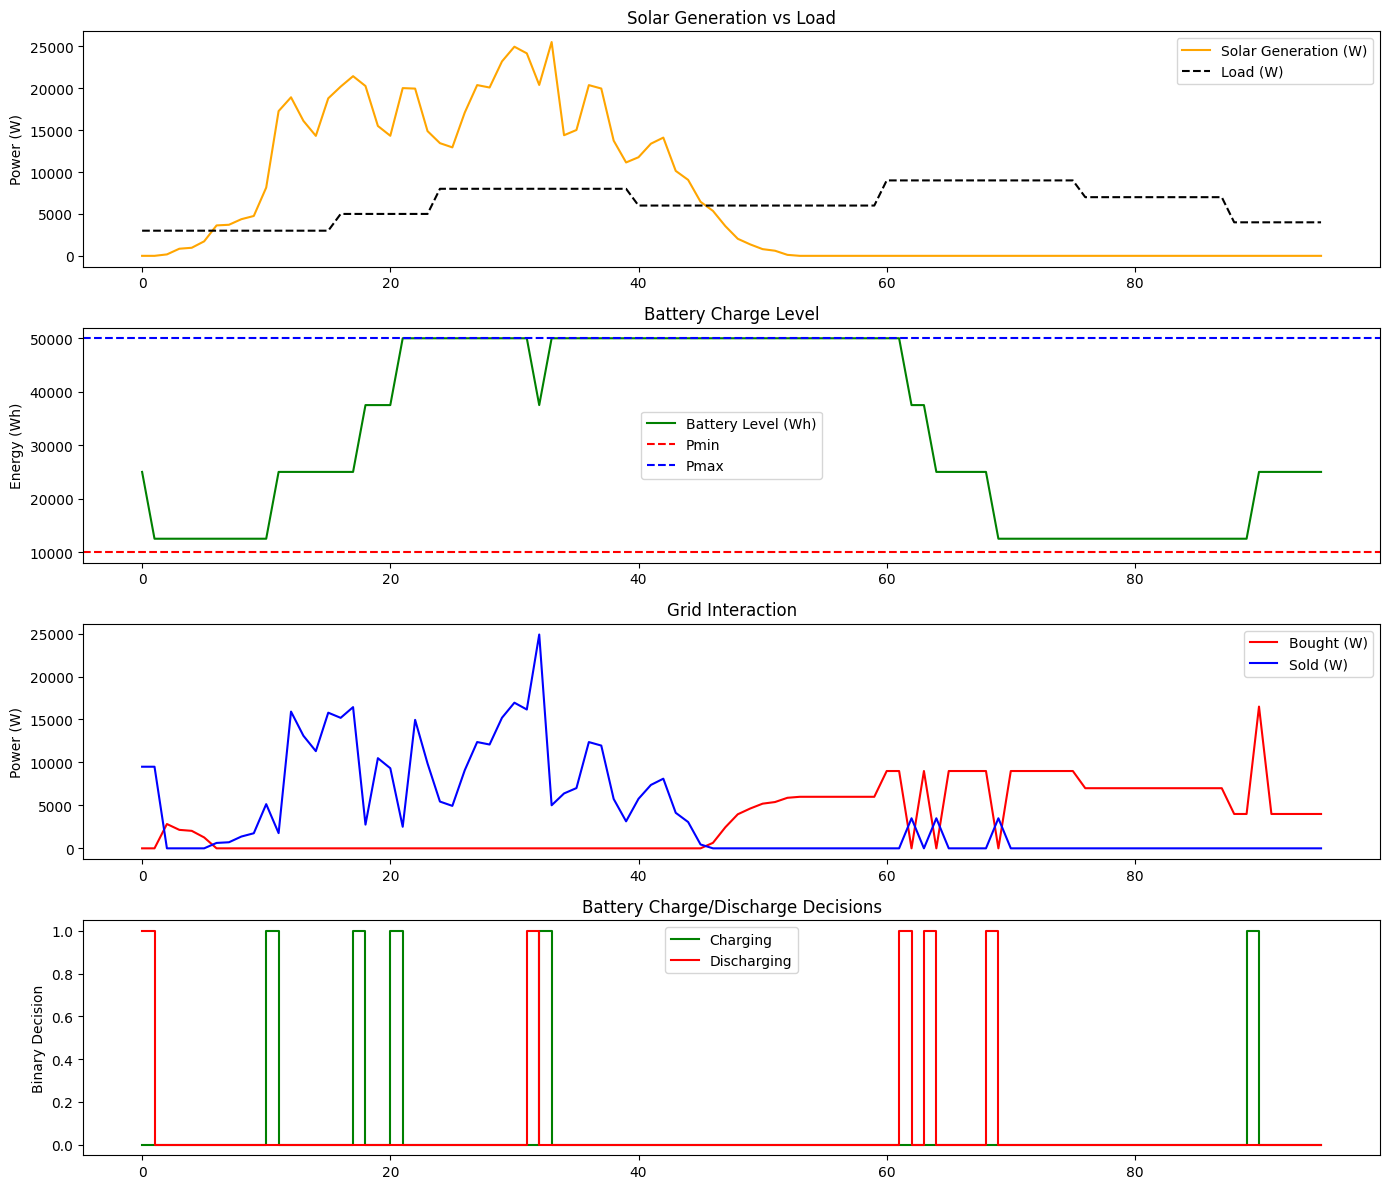

In [40]:
import matplotlib.pyplot as plt

bt_vals = [bt[t].X for t in range(T)]
st_vals = [st[t].X for t in range(T)]
Pt_vals = [Pt[t].X for t in range(T)]
ct_vals = [ct[t].X for t in range(T)]
dt_vals = [dt[t].X for t in range(T)]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# solar generation vs load
axes[0].plot(St_values, color='orange', label='Solar Generation (W)')
axes[0].plot(load, color='black', linestyle='--', label='Load (W)')
axes[0].set_ylabel('Power (W)')
axes[0].legend()
axes[0].set_title('Solar Generation vs Load')

# battery level
axes[1].plot(Pt_vals, color='green', label='Battery Level (Wh)')
axes[1].axhline(P_MIN, color='red', linestyle='--', label='Pmin')
axes[1].axhline(P_MAX, color='blue', linestyle='--', label='Pmax')
axes[1].set_ylabel('Energy (Wh)')
axes[1].legend()
axes[1].set_title('Battery Charge Level')

# grid interaction
axes[2].plot(bt_vals, color='red', label='Bought (W)')
axes[2].plot(st_vals, color='blue', label='Sold (W)')
axes[2].set_ylabel('Power (W)')
axes[2].legend()
axes[2].set_title('Grid Interaction')

# charge discharge decisions
axes[3].step(range(T), ct_vals, color='green', label='Charging')
axes[3].step(range(T), dt_vals, color='red', label='Discharging')
axes[3].set_ylabel('Binary Decision')
axes[3].legend()
axes[3].set_title('Battery Charge/Discharge Decisions')

plt.tight_layout()
plt.show()